In [2]:
import os
import requests

API_KEY = os.environ.get("NREL_API_KEY")
if not API_KEY:
    raise RuntimeError(
        "Set the NREL_API_KEY environment variable before running this "
        "cell -- see the markdown cell above for how."
    )

url = "https://developer.nlr.gov/api/nsrdb/v2/solar/himawari-download.csv"
params = {
    "api_key": API_KEY,
    "email": os.environ.get("NREL_EMAIL", "saiyedfaiez@gmail.com"),
    "wkt": "POINT(75.9235 22.5297)",  # IIT Indore campus (longitude latitude)
    "names": "2019",
    "leap_day": "false",
    "interval": "10",
    "utc": "false",
    "mailing_list": "false",
}

response = requests.get(url, params=params)
with open("himawari_2019_data.csv", "wb") as f:
    f.write(response.content)

print("Download complete: himawari_2019_data.csv")

Download complete: himawari_2019_data.csv


In [3]:
!pip install requests prophet pandas matplotlib scikit-learn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 66.2 MB/s eta 0:00:00


['Year', 'Month', 'Day', 'Hour', 'Minute', 'Temperature', 'Alpha', 'Aerosol Optical Depth', 'Asymmetry', 'Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI', 'Cloud Type', 'Dew Point', 'DHI', 'DNI', 'Fill Flag', 'GHI', 'Ozone', 'Relative Humidity', 'Solar Zenith Angle', 'Surface Albedo', 'Pressure', 'Precipitable Water', 'Wind Direction', 'Wind Speed']


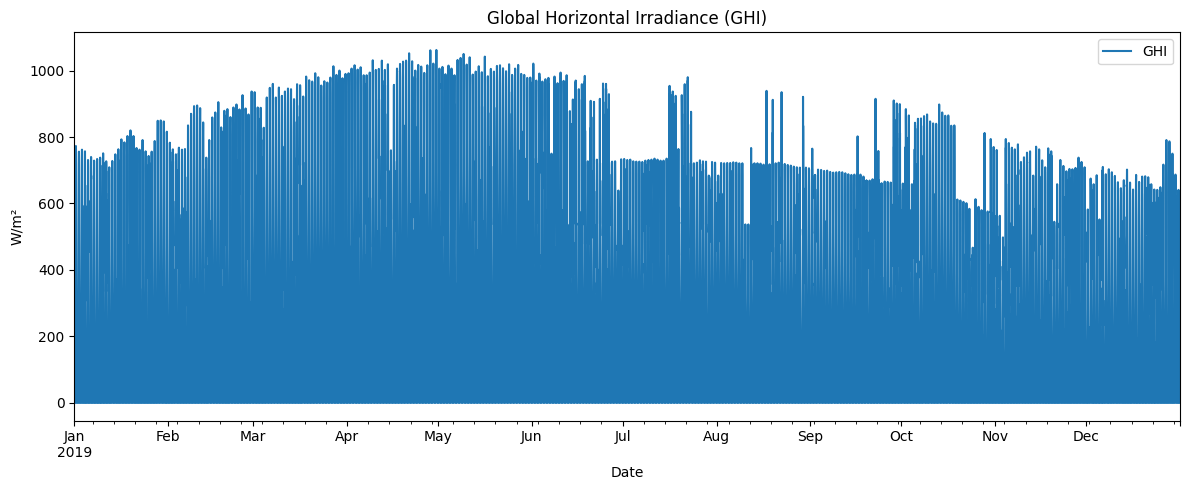

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("himawari_2019_data.csv", skiprows=2)
print(df.columns.tolist())

df['Timestamp'] = pd.to_datetime(dict(
    year=df['Year'], month=df['Month'], day=df['Day'],
    hour=df['Hour'], minute=df['Minute']
))
df.set_index('Timestamp', inplace=True)

plt.figure(figsize=(12, 5))
df['GHI'].plot(label='GHI')
plt.title("Global Horizontal Irradiance (GHI)")
plt.ylabel("W/m²")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

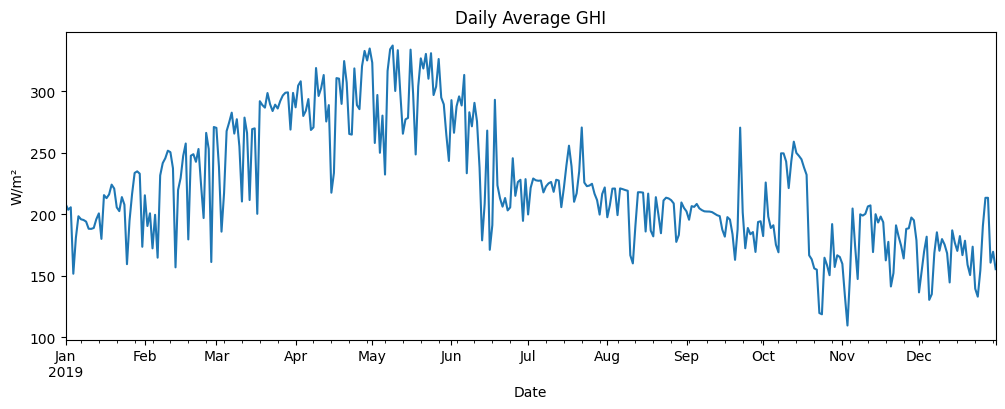

In [5]:
df['GHI'].resample('D').mean().plot(figsize=(12, 4), title='Daily Average GHI')
plt.ylabel('W/m²')
plt.xlabel('Date')
plt.show()


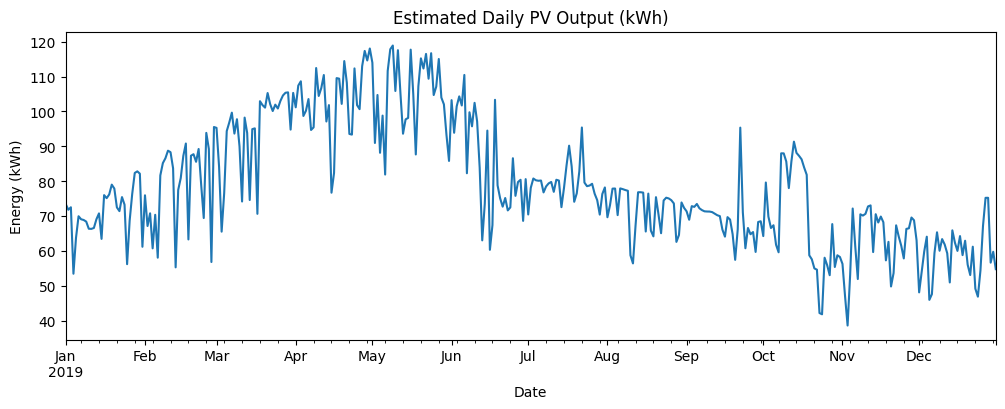

Estimated annual output: 28,843 kWh


In [6]:
# System specifications
panel_area = 1.6          # m^2 per panel
panel_efficiency = 0.18   # 18%
num_panels = 10
derating_factor = 0.85    # wiring, inverter, and other real-world losses

df['PV_output_kw'] = (
    df['GHI'] * panel_area * num_panels * panel_efficiency * derating_factor
) / 1000  # W -> kW

daily_energy = df['PV_output_kw'].resample('D').sum()
daily_energy.plot(figsize=(12, 4), title="Estimated Daily PV Output (kWh)")
plt.ylabel("Energy (kWh)")
plt.xlabel("Date")
plt.show()

print(f"Estimated annual output: {daily_energy.sum():,.0f} kWh")


In [7]:
df['T_cell'] = df['Temperature'] + (df['GHI'] / 800) * 20  # simple NOCT-style estimate
beta = 0.004  # ~0.4% efficiency loss per °C above 25

df['eff_temp'] = panel_efficiency * (1 - beta * (df['T_cell'] - 25))
df['PV_output_kw_temp'] = (
    df['GHI'] * panel_area * num_panels * df['eff_temp'] * derating_factor
) / 1000

daily_energy_temp = df['PV_output_kw_temp'].resample('D').sum()
print(f"Base model annual total:        {daily_energy.sum():,.0f} kWh")
print(f"Temperature-adjusted annual total: {daily_energy_temp.sum():,.0f} kWh")

Base model annual total:        28,843 kWh
Temperature-adjusted annual total: 26,292 kWh


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


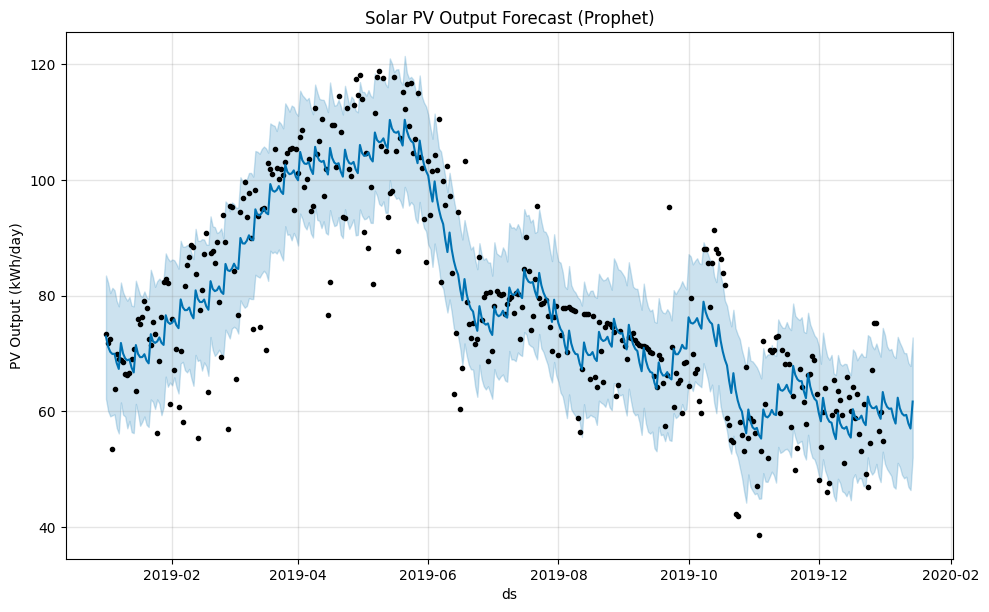

In [8]:
from prophet import Prophet

df_prophet = daily_energy.reset_index()
df_prophet.columns = ['ds', 'y']

# Yearly seasonality needs ~2 years of history to fit reliably --
# Prophet will warn (not error) if given less, as here with 1 year.
model = Prophet(yearly_seasonality=True)
model.fit(df_prophet)

future = model.make_future_dataframe(periods=14, freq='D')
forecast = model.predict(future)

model.plot(forecast)
plt.title("Solar PV Output Forecast (Prophet)")
plt.ylabel("PV Output (kWh/day)")
plt.show()

In [9]:
from google.colab import files
uploaded = files.upload()

Saving app.py to app.py


In [15]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦your url is: https://wicked-cooks-hug.loca.lt

y


In [13]:
!cat /content/logs.txt



2026-09-13 16:04:43.280 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.61.114.233:8501

  Stopping...
